In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

In [67]:
data = pd.read_parquet('../data/data_full.parquet')
data.dropna(subset=['z','logD25'], inplace=True)

In [68]:
data['r-g'] = data['r']-data['g']
data['logD25'] = data['logD25'].astype(float)

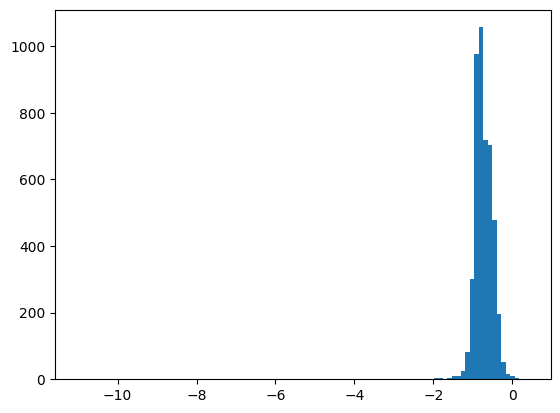

In [69]:
plt.hist(data['r-g'], bins=100)
plt.show()

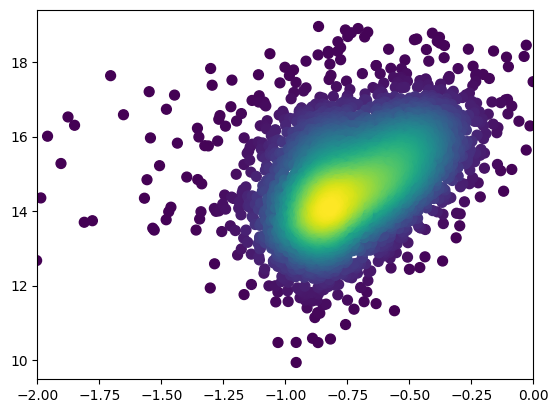

In [84]:
# Calculate the point density
x = data['r-g'].to_numpy()
y = data['r'].to_numpy()
xy = np.vstack([x,y])
z = gaussian_kde(xy)(xy)

# Sort the points by density, so that the densest points are plotted last
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]

fig, ax = plt.subplots()
ax.scatter(x, y, c=z, s=50)
ax.set_xlim([-2.,0.])
plt.show()